## Improrting libraries

In [1]:
!pip install tensorflow
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

Mounted at /content/drive


## Importing the datasets

### Train/val/test in colab disk

In [17]:
# !pip install split-folders

In [18]:
# import splitfolders
# import os

In [20]:
# input_folder = '/content/drive/MyDrive/ml-datasets/painters/resized_training'
# output_folder = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset'

# split_ratio = (0.8, 0.1, 0.1)

# splitfolders.ratio(
#     input_folder,
#     output=output_folder,
#     seed=42,
#     ratio=split_ratio,
#     group_prefix=None,
#     move=False
# )


Copying files: 0 files [00:00, ? files/s]
Copying files: 1 files [00:00,  3.85 files/s]
Copying files: 8 files [00:00, 26.91 files/s]
Copying files: 13 files [00:00, 34.56 files/s]
Copying files: 19 files [00:00, 41.83 files/s]
Copying files: 24 files [00:00, 44.12 files/s]
Copying files: 31 files [00:00, 44.19 files/s]
Copying files: 36 files [00:00, 43.91 files/s]
Copying files: 42 files [00:01, 47.03 files/s]
Copying files: 47 files [00:01, 46.41 files/s]
Copying files: 53 files [00:01, 44.15 files/s]
Copying files: 59 files [00:01, 44.12 files/s]
Copying files: 65 files [00:01, 46.03 files/s]
Copying files: 71 files [00:01, 48.86 files/s]
Copying files: 76 files [00:01, 46.97 files/s]
Copying files: 82 files [00:01, 48.70 files/s]
Copying files: 88 files [00:02, 46.33 files/s]
Copying files: 93 files [00:02, 46.21 files/s]
Copying files: 98 files [00:02, 43.75 files/s]
Copying files: 104 files [00:02, 45.94 files/s]
Copying files: 109 files [00:02, 43.85 files/s]
Copying files: 11

### Tensorflow datasets import from disk

In [46]:
train_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/train'
val_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/val'
test_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/test'

train = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=32,
    image_size=(224, 224),
    verbose=True
)

val = tf.keras.preprocessing.image_dataset_from_directory(
    val_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=32,
    image_size=(224, 224),
    verbose=True
)

test = tf.keras.preprocessing.image_dataset_from_directory(
    test_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=32,
    image_size=(224, 224),
    verbose=True
)

Found 2456 files belonging to 27 classes.
Found 296 files belonging to 27 classes.
Found 327 files belonging to 27 classes.


27


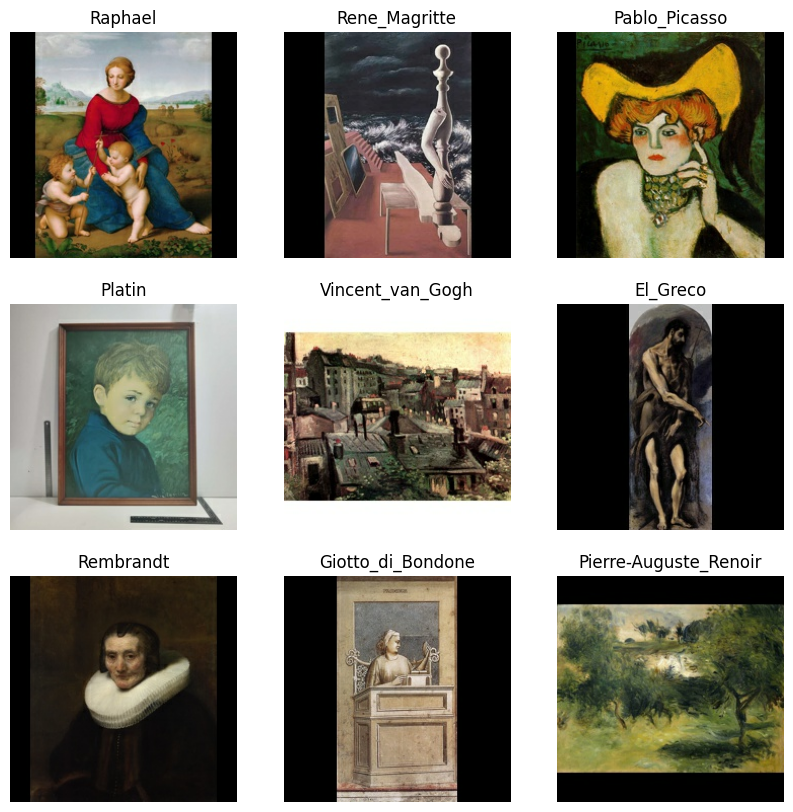

In [47]:
class_names = train.class_names
print(len(class_names))

plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
  break

# CNN Implementation

In [5]:
def model_builder(hp):
  # Define the model's input
  inputs = keras.Input(shape=(224, 224, 3))

  # Apply data augmentation layers sequentially to the tensor
  x = keras.layers.RandomFlip("horizontal")(inputs)
  x = keras.layers.RandomRotation(0.03)(x)

  #Normalizing the data
  x = keras.layers.Rescaling(scale=1./255) (x)

  # Load the base model and set it to non-trainable
  base_model = tf.keras.applications.EfficientNetB0(
      include_top=False,
      input_shape=(224, 224, 3),
      pooling='avg',
  )
  base_model.trainable = False

  # Pass the augmented input tensor to the base_model
  x = base_model(x)

  # Add custom top layers
  x = tf.keras.layers.Dropout(0.35)(x)
  outputs = tf.keras.layers.Dense(27, activation='softmax')(x)

  # Create the final model
  model = tf.keras.Model(inputs=inputs, outputs=outputs)

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
      metrics=['accuracy']
  )

  return model

In [6]:
tuner = kt.Hyperband(
    model_builder,
    objective='accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='best_params'
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=5
)

tuner.search(x=train, epochs=50, callbacks=[stop_early])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
0.001             |0.001             |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2


KeyboardInterrupt: 

In [ ]:
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_params)
model = tuner.hypermodel.build(best_params)
history = model.fit(train, epochs=5)

In [ ]:
model.evaluate(test)

In [ ]:
for images, labels in test.take(1):
  ax = plt.subplot(3, 3, 1)
  plt.imshow(images[2].numpy().astype("uint8"))
  plt.title(class_names[labels[2]])
  plt.axis("off")

  # Add a batch dimension to the single image before prediction
  single_image = np.expand_dims(images[2].numpy(), axis=0)
  predictions = model.predict(single_image)
  print("Model prediction (probabilities):", predictions)
  predicted_class = np.argmax(predictions)
  print(f"\n\nPredicted class: {class_names[predicted_class]}")
  print(f"True class: {class_names[labels[2]]}")
  break

In [ ]:
model.save('model.keras')